In [2]:
import spatialdata as sd 
import spatialdata_io as sio
from napari_spatialdata import Interactive
from spatialdata.models import Image2DModel
from dask_image.imread import imread
import squidpy as sq
import scanpy as sc
import spatialdata as sd
import pandas as pd

c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Xenium = sio.xenium('C://Users//laure//Desktop//github//Masterpraktikum//main_task//Version 2//Sample 4H', morphology_mip=False)

INFO     reading C:\Users\laure\Desktop\github\Masterpraktikum\main_task\Version 2\Sample 4H\cell_feature_matrix.h5


In [3]:
#image = imread("1.4H.tiff")
#Xenium.images["1.4H.tiff"] = Image2DModel.parse(image.squeeze(), dims=("y", "x", "c"), scale_factors=(2,2,2))

INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           


In [4]:
#Xenium.write("Version 2 Zarr//Sample 4H.zarr")

In [3]:
cell_annotation = sc.read_h5ad("RUN2_spatial_annot.h5ad")
adata = sc.read_h5ad("Version_2_all_samples_Xenium_segmentation.h5ad")

C:\Users\laure\AppData\Roaming\Python\Python39\site-packages\anndata\_core\anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [7]:
cell_annotation

AnnData object with n_obs × n_vars = 72952 × 345
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'n_genes', 'size_factors', 'd_or_h', 'leiden', 'cell_type_level1'
    obsm: 'Harmony', 'X_pca', 'X_umap', 'spatial'

In [8]:
adata.obs = adata.obs.merge(cell_annotation.obs[['cell_id', 'cell_type_level1']], on='cell_id', how='left')

In [10]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,cell_labels,plaque_region,sample,condition,batch,n_counts,n_genes,leiden,cell_type_level1
0,aaafemjc-1,17,0,0,0,0,17,242.534228,7.089532,cell_circles,1,Media,1H,healthy,0,17.0,10,2,SMC
1,aacmgobk-1,63,0,0,0,0,63,378.138451,46.194845,cell_circles,2,Media,1H,healthy,0,63.0,29,5,Fibroblast
2,aacnddfj-1,105,0,0,0,0,105,363.282044,62.270471,cell_circles,3,Media,1H,healthy,0,105.0,44,10,SMC
3,aadlinli-1,85,0,0,0,0,85,999.714255,36.847501,cell_circles,4,Media,1H,healthy,0,85.0,37,10,SMC
4,aaehmplc-1,57,0,0,0,0,57,1201.472387,52.200627,cell_circles,6,Media,1H,healthy,0,57.0,20,0,SMC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72947,ojejhbel-1,54,0,0,0,0,54,206.318914,16.211094,cell_circles,25202,Media,4D,diseased,7,54.0,44,6,unknown
72948,ojekmkpi-1,27,0,0,0,0,27,124.947348,10.702032,cell_circles,25203,Media,4D,diseased,7,27.0,23,6,Fibroblast
72949,ojenmjec-1,46,0,0,0,0,46,513.426581,12.147032,cell_circles,25204,Media,4D,diseased,7,46.0,38,11,Macrophage
72950,ojfafaeg-1,28,0,0,0,0,28,53.103752,11.921250,cell_circles,25205,Media,4D,diseased,7,28.0,24,1,unknown


In [3]:
sc.pp.filter_cells(adata, min_counts=5)
sc.pp.filter_cells(adata, min_genes=5)
adata

AnnData object with n_obs × n_vars = 72952 × 345
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'plaque_region', 'sample', 'condition', 'batch', 'n_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [4]:
sc.pp.neighbors(adata, n_neighbors=10)

         Falling back to preprocessing with `sc.pp.pca` and default params.


In [5]:
sc.tl.umap(adata)

In [6]:
sc.tl.leiden(adata, resolution=1)

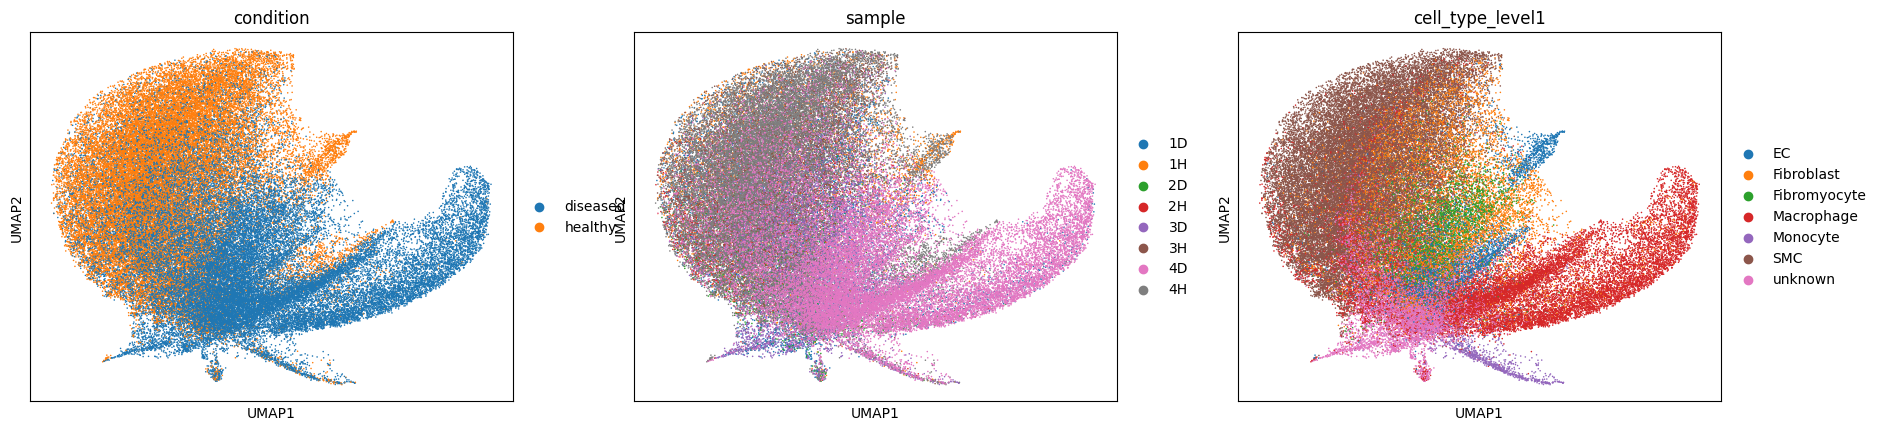

In [7]:
sc.pl.umap(adata, color=["condition","sample","cell_type_level1"], s=5)

In [12]:
adata.write("Version_2_all_samples_Xenium_segmentation.h5ad")

In [3]:
sc.tl.rank_genes_groups(adata, groupby="condition", method="wilcoxon", corr_method="bonferroni")

In [4]:
sc.tl.rank_genes_groups(adata, groupby="sample", method="wilcoxon", corr_method="bonferroni")

In [5]:
adata.uns["rank_genes_groups"]

{'params': {'groupby': 'sample',
  'reference': 'rest',
  'method': 'wilcoxon',
  'use_raw': False,
  'layer': None,
  'corr_method': 'bonferroni'},
 'names': rec.array([('SNHG14', 'MYH11', 'CD7', 'MYH11', 'CPA3', 'ACTA2', 'IFI30', 'ACTA2'),
            ('CPA3', 'ACTA2', 'AMH', 'ACTA2', 'EDN1', 'MYH11', 'SPP1', 'MYH11'),
            ('EDN1', 'SNHG14', 'WNT6', 'ANTXR1', 'SNHG14', 'ITGB1', 'CD68', 'ANTXR1'),
            ('CARMN', 'COL1A2', 'HSPB9', 'MFGE8', 'DCN', 'SNHG14', 'MSR1', 'ITGB1'),
            ('PARP1', 'ANTXR1', 'TCAP', 'PTGIS', 'PARP1', 'ANTXR1', 'ABCA1', 'COL1A2'),
            ('VPS33A', 'ITGB1', 'C2CD4D', 'CARMN', 'FTX', 'COL1A2', 'TMSB10', 'CNN1'),
            ('STAT3', 'CDH13', 'TPSAB1', 'COL1A2', 'IFI44L', 'PTGIS', 'S100A11', 'SNHG14'),
            ('RERGL', 'PTGIS', 'ZNF683', 'UNC13A', 'VPS33A', 'CARMN', 'CD36', 'PTGIS'),
            ('GADD45A', 'ITGB5', 'MAP1S', 'CD7', 'STAT3', 'CDH13', 'CD14', 'IPO7'),
            ('CX3CR1', 'DCN', 'CCNA2', 'WNT6', 'MAF', 'ITGB5', 'IT

In [6]:
names = adata.uns["rank_genes_groups"]["names"]
pvals = adata.uns["rank_genes_groups"]["pvals"]
pvals_adj = adata.uns["rank_genes_groups"]["pvals_adj"]
logFC = adata.uns["rank_genes_groups"]["logfoldchanges"]

In [51]:
data = []
condition = '2H'
for i in range(len(names)):
    data.append((names[i][condition], pvals[i][condition], pvals_adj[i][condition], logFC[i][condition]))


In [52]:
degs = pd.DataFrame(data, columns=["names", "pvals", "pvals_adj", "logFC"])
degs

,names,pvals,pvals_adj,logFC
0,MYH11,4.416181e-56,1.523582e-53,-0.303757
1,ACTA2,1.320285e-04,4.554983e-02,-1.682710
2,ANTXR1,1.772836e-01,1.000000e+00,-0.321623
3,MFGE8,3.676226e-01,1.000000e+00,0.075042
4,PTGIS,3.683022e-01,1.000000e+00,-0.293773
...,...,...,...,...
340,TMSB10,4.235742e-49,1.461331e-46,-2.759262
341,ZEB2,6.863339e-51,2.367852e-48,-1.670133
342,S100A11,9.349324e-59,3.225517e-56,-2.413324
343,CD68,6.453586e-73,2.226487e-70,-4.827651


In [53]:
degs.to_csv("Version_2_Xenium_segmentation_DEGs_by_2H_vs_rest.csv", index=False)

In [3]:
Sample_1H = sd.read_zarr('Version 2 Zarr//Sample_1H_annotated.zarr')
Sample_1H.tables["table"].obs["sample"] = "1H"
Sample_1H.tables["table"].obs["condition"] = "healthy"
adata_1H = Sample_1H.tables["table"]

Sample_1D = sd.read_zarr('Version 2 Zarr//Sample_1D_annotated.zarr')
Sample_1D.tables["table"].obs["sample"] = "1D"
Sample_1D.tables["table"].obs["condition"] = "diseased"
adata_1D = Sample_1D.tables["table"]

Sample_2H = sd.read_zarr('Version 2 Zarr//Sample_2H_annotated.zarr')
Sample_2H.tables["table"].obs["sample"] = "2H"
Sample_2H.tables["table"].obs["condition"] = "healthy"
adata_2H = Sample_2H.tables["table"]

Sample_2D = sd.read_zarr('Version 2 Zarr//Sample_2D_annotated.zarr')
Sample_2D.tables["table"].obs["sample"] = "2D"
Sample_2D.tables["table"].obs["condition"] = "diseased"
adata_2D = Sample_2D.tables["table"]

Sample_3H = sd.read_zarr('Version 2 Zarr//Sample_3H_annotated.zarr')
Sample_3H.tables["table"].obs["sample"] = "3H"
Sample_3H.tables["table"].obs["condition"] = "healthy"
adata_3H = Sample_3H.tables["table"]

Sample_3D = sd.read_zarr('Version 2 Zarr//Sample_3D_annotated.zarr')
Sample_3D.tables["table"].obs["sample"] = "3D"
Sample_3D.tables["table"].obs["condition"] = "diseased"
adata_3D = Sample_3D.tables["table"]

Sample_4H = sd.read_zarr('Version 2 Zarr//Sample_4H_annotated.zarr')
Sample_4H.tables["table"].obs["sample"] = "4H"
Sample_4H.tables["table"].obs["condition"] = "healthy"
adata_4H = Sample_4H.tables["table"]

Sample_4D = sd.read_zarr('Version 2 Zarr//Sample_4D_annotated.zarr')
Sample_4D.tables["table"].obs["sample"] = "4D"
Sample_4D.tables["table"].obs["condition"] = "diseased"
adata_4D = Sample_4D.tables["table"]

In [4]:
all_samples = adata_1H.concatenate([adata_1D, adata_2H, adata_2D, adata_3H, adata_3D, adata_4H, adata_4D])

In [5]:
all_samples.write_h5ad("Version_2_all_samples_Xenium_segmentation.h5ad")

In [4]:
adata = sc.read_h5ad("Version_2_all_samples_Xenium_segmentation.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 110060 × 345
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'plaque_region', 'sample', 'condition', 'batch'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [7]:
Xenium.tables["table"].obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,cell_labels,plaque_region
0,aaafemjc-1,17,0,0,0,0,17,242.534228,7.089532,cell_circles,1,Media
1,aacmgobk-1,63,0,0,0,0,63,378.138451,46.194845,cell_circles,2,Media
2,aacnddfj-1,105,0,0,0,0,105,363.282044,62.270471,cell_circles,3,Media
3,aadlinli-1,85,0,0,0,0,85,999.714255,36.847501,cell_circles,4,Media
4,aadpgchk-1,1,0,0,0,0,1,698.702682,67.598909,cell_circles,5,Media
...,...,...,...,...,...,...,...,...,...,...,...,...
6337,ohheocmm-1,45,0,0,0,0,45,363.778763,64.844377,cell_circles,6338,Media
6338,ohhhghpp-1,15,0,0,0,0,15,136.913755,15.533751,cell_circles,6339,Media
6339,ohhipoaa-1,33,0,0,0,0,33,639.322211,34.363907,cell_circles,6340,Media
6340,ohhlbgal-1,14,0,0,0,0,14,268.679697,30.706251,cell_circles,6341,Media
